In [ ]:
import numpy as np
import pickle
import json

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_data = np.load('../data/processed/train_data.npz')
val_data = np.load('../data/processed/val_data.npz')
test_data = np.load('../data/processed/test_data.npz')

In [ ]:
# Extract Proccessed Data
X_train, y_train = train_data['X'], train_data['y']
X_val, y_val = val_data['X'], val_data['y']
X_test, y_test = test_data['X'], test_data['y']

In [ ]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((3480, 224, 224, 3),
 (3480,),
 (746, 224, 224, 3),
 (746,),
 (746, 224, 224, 3),
 (746,))

In [ ]:
# Get number of classes
with open('../data/processed/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
num_classes= len(label_encoder.classes_)
print(f'Number of classes: {num_classes}')

Number of classes: 24


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
label_encoder.classes_

array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N',
       'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y'], dtype='<U1')

In [1]:
import sys
import os

# Add parent directory to path so we can import src module
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# Build and train model
from src.model import SignLanguageModel_ResNet50
from src.training import TrainingPipeline

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,148,248 (92.12 MB)

 Trainable params: 20,013,464 (76.35 MB)

 Non-trainable params: 4,134,784 (15.77 MB)

None


In [ ]:
# Build Model
model_builder = SignLanguageModel_ResNet50(num_classes)
model = model_builder.build_model()
model = model_builder.compile_model(model)

In [ ]:
# Train Model
config = {
    'batch_size': 32,
    'epochs': 100
}
trainer = TrainingPipeline(model, config)
history = trainer.train(X_train, y_train, X_val, y_val, '../models/best_model.h5')


Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.0925 - loss: 3.0777
Epoch 1: val_accuracy improved from None to 0.04960, saving model to /content/drive/MyDrive/Harshil/models/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Harshil/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 93s 503ms/step - accuracy: 0.1417 - loss: 2.8080 - val_accuracy: 0.0496 - val_loss: 389.1111 - learning_rate: 0.0010
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.2584 - loss: 2.2487
Epoch 2: val_accuracy did not improve from 0.04960
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 193ms/step - accuracy: 0.3052 - loss: 2.0800 - val_accuracy: 0.0496 - val_loss: 198.1618 - learning_rate: 0.0010
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.4769 - loss: 1.5658
Epoch 3: val_accuracy improved from 0.04960 to 0.05094, saving model to /content/drive/MyDrive/Harshil/models/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Harshil/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 259ms/step - accuracy: 0.5043 - loss: 1.4736 - val_accuracy: 0.0509 - val_loss: 19.0394 - learning_rate: 0.0010
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.6158 - loss: 1.1078
Epoch 4: val_accuracy improved from 0.05094 to 0.07373, saving model to /content/drive/MyDrive/Harshil/models/best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Harshil/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 242ms/step - accuracy: 0.6615 - loss: 0.9662 - val_accuracy: 0.0737 - val_loss: 24.0815 - learning_rate: 0.0010
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7387 - loss: 0.7701
Epoch 5: val_accuracy improved from 0.07373 to 0.52413, saving model to /content/drive/MyDrive/Harshil/models/best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Harshil/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 31s 287ms/step - accuracy: 0.7549 - loss: 0.7264 - val_accuracy: 0.5241 - val_loss: 3.5002 - learning_rate: 0.0010
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8048 - loss: 0.5700
Epoch 6: val_accuracy did not improve from 0.52413
109/109 ━━━━━━━━━━━━━━━━━━━━ 31s 195ms/step - accuracy: 0.8043 - loss: 0.5731 - val_accuracy: 0.0402 - val_loss: 31.3809 - learning_rate: 0.0010
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8414 - loss: 0.4927
Epoch 7: val_accuracy did not improve from 0.52413
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - accuracy: 0.8348 - loss: 0.5154 - val_accuracy: 0.0496 - val_loss: 25.3422 - learning_rate: 0.0010
Epoch 8/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8587 - loss: 0.3957
Epoch 8: val_accuracy did not improve from 0.52413
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.8

...


Epoch 12: finished saving model to /content/drive/MyDrive/Harshil/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 36s 331ms/step - accuracy: 0.9273 - loss: 0.2057 - val_accuracy: 0.9370 - val_loss: 0.1844 - learning_rate: 0.0010
Epoch 13/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9341 - loss: 0.1894
Epoch 13: val_accuracy did not improve from 0.93700
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy: 0.9359 - loss: 0.1917 - val_accuracy: 0.9155 - val_loss: 0.2829 - learning_rate: 0.0010
Epoch 14/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9455 - loss: 0.1636
Epoch 14: val_accuracy improved from 0.93700 to 0.94638, saving model to /content/drive/MyDrive/Harshil/models/best_model.h5



Epoch 14: finished saving model to /content/drive/MyDrive/Harshil/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 38s 352ms/step - accuracy: 0.9494 - loss: 0.1537 - val_accuracy: 0.9464 - val_loss: 0.2227 - learning_rate: 0.0010
Epoch 15/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9375 - loss: 0.2426
Epoch 15: val_accuracy did not improve from 0.94638
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.9250 - loss: 0.2601 - val_accuracy: 0.7761 - val_loss: 0.8295 - learning_rate: 0.0010
Epoch 16/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9589 - loss: 0.1140
Epoch 16: val_accuracy improved from 0.94638 to 0.98928, saving model to /content/drive/MyDrive/Harshil/models/best_model.h5



Epoch 16: finished saving model to /content/drive/MyDrive/Harshil/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 30s 277ms/step - accuracy: 0.9583 - loss: 0.1123 - val_accuracy: 0.9893 - val_loss: 0.0406 - learning_rate: 0.0010
Epoch 17/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9689 - loss: 0.1072
Epoch 17: val_accuracy did not improve from 0.98928
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.9603 - loss: 0.1292 - val_accuracy: 0.9772 - val_loss: 0.0709 - learning_rate: 0.0010
Epoch 18/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9567 - loss: 0.1369
Epoch 18: val_accuracy did not improve from 0.98928
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.9606 - loss: 0.1250 - val_accuracy: 0.9705 - val_loss: 0.1047 - learning_rate: 0.0010
Epoch 19/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9657 - loss: 0.1159
Epoch 19: val_accuracy did not improve from 0.98928
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy


Epoch 21: finished saving model to /content/drive/MyDrive/Harshil/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 36s 335ms/step - accuracy: 0.9698 - loss: 0.0963 - val_accuracy: 0.9946 - val_loss: 0.0188 - learning_rate: 0.0010
Epoch 22/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9756 - loss: 0.0830
Epoch 22: val_accuracy did not improve from 0.99464
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 188ms/step - accuracy: 0.9710 - loss: 0.0978 - val_accuracy: 0.8418 - val_loss: 0.7108 - learning_rate: 0.0010
Epoch 23/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9593 - loss: 0.1223
Epoch 23: val_accuracy did not improve from 0.99464
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - accuracy: 0.9675 - loss: 0.1043 - val_accuracy: 0.9906 - val_loss: 0.0299 - learning_rate: 0.0010
Epoch 24/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9616 - loss: 0.1181
Epoch 24: val_accuracy did not improve from 0.99464
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - accuracy


Epoch 31: finished saving model to /content/drive/MyDrive/Harshil/models/best_model.h5
109/109 ━━━━━━━━━━━━━━━━━━━━ 35s 319ms/step - accuracy: 0.9833 - loss: 0.0544 - val_accuracy: 0.9987 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 32/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9809 - loss: 0.0730
Epoch 32: val_accuracy did not improve from 0.99866
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.9787 - loss: 0.0726 - val_accuracy: 0.9946 - val_loss: 0.0374 - learning_rate: 0.0010
Epoch 33/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9889 - loss: 0.0409
Epoch 33: val_accuracy did not improve from 0.99866
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - accuracy: 0.9868 - loss: 0.0495 - val_accuracy: 0.8981 - val_loss: 0.3989 - learning_rate: 0.0010
Epoch 34/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9759 - loss: 0.0888
Epoch 34: val_accuracy did not improve from 0.99866
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy

In [ ]:
with open('../results/training_history.json', 'w') as f:
    json.dump({
        'loss': history.history['loss'],
        'val_loss': history.history['val_loss'],
        'accuracy': history.history['accuracy'],
        'val_accuracy': history.history['val_accuracy']
    }, f)

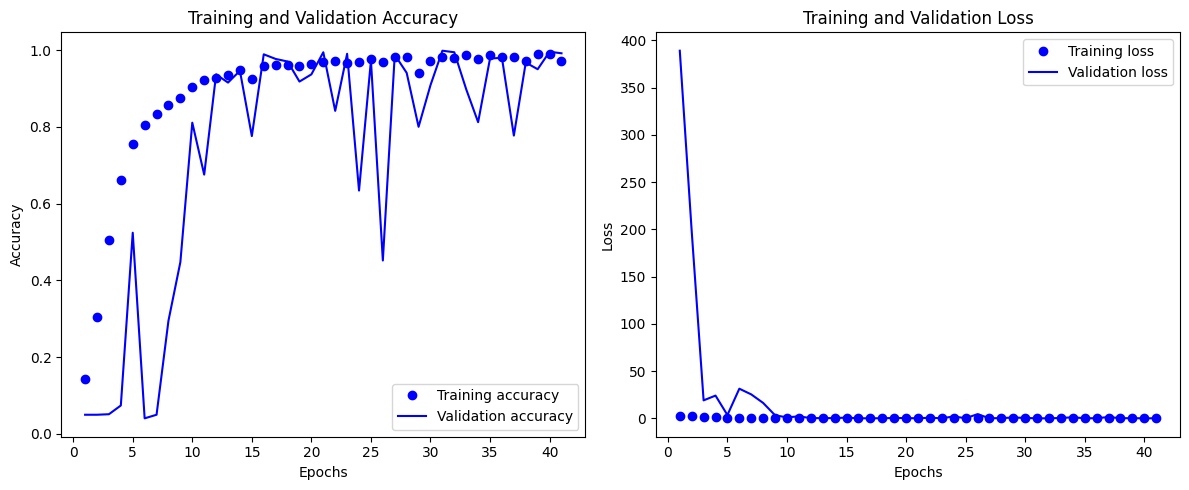

In [ ]:
import matplotlib.pyplot as plt

# Get the history data
history_dict = history.history

# Get the number of epochs
epochs = range(1, len(history_dict['loss']) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Training accuracy')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

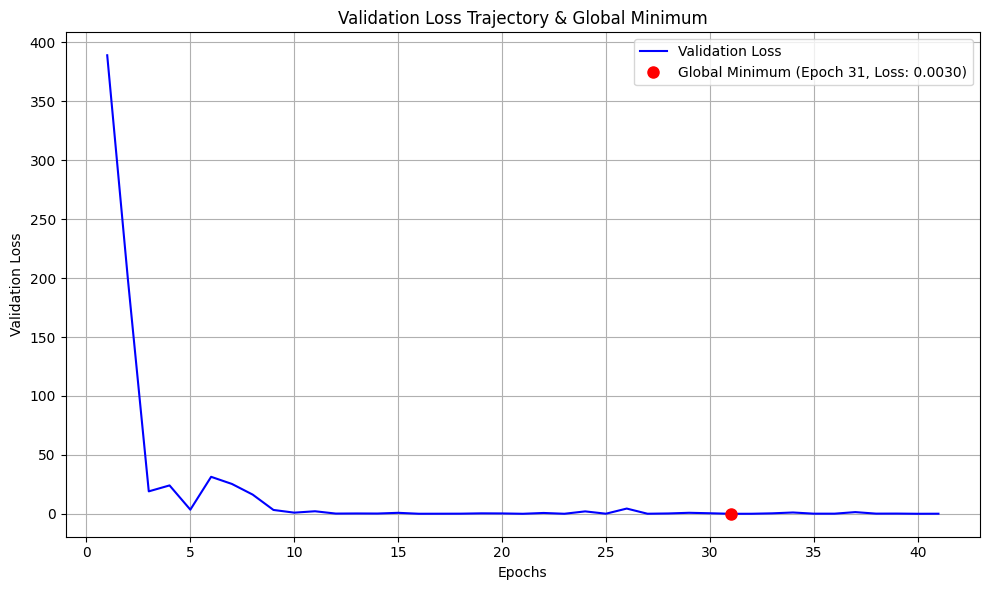

In [ ]:
import matplotlib.pyplot as plt

# Get the history data
history_dict = history.history

# Get the number of epochs
epochs = range(1, len(history_dict['val_loss']) + 1)

# Find the global minimum of validation loss
min_val_loss = min(history_dict['val_loss'])
min_val_loss_epoch = history_dict['val_loss'].index(min_val_loss) + 1

plt.figure(figsize=(10, 6))
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation Loss')
plt.plot(min_val_loss_epoch, min_val_loss, 'ro', markersize=8, label=f'Global Minimum (Epoch {min_val_loss_epoch}, Loss: {min_val_loss:.4f})')
plt.title('Validation Loss Trajectory & Global Minimum')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()